# Pitchfork Reviews — Exploratory Data Analysis

Charts and distributions over the cleaned Pitchfork review dataset produced by `fork_fetch.py`. This notebook is for exploration only — production filtering and exporting selections (e.g. for playlists) lives in `fork.py`, not here.

In [733]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 110


def find_project_dir(pattern: str, start: Path = Path.cwd()) -> Path:
    """Walk up from `start` to the nearest directory containing files matching `pattern`.

    VS Code / Jupyter run the notebook with its own directory as the working
    directory (e.g. notebooks/), while the data files live in the project root
    one level up, so a plain Path(".").glob(...) finds nothing there.
    """
    for d in (start, *start.parents):
        if any(d.glob(pattern)):
            return d
    raise FileNotFoundError(f"No files matching {pattern!r} found in {start} or its parents")


project_dir = find_project_dir("data/fork_data_prepared_*.tsv")

FIG_DIR = project_dir / "figures"
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name: str) -> None:
    """Save `fig` as figures/<name>.png — call it before plt.show(), which can clear the figure."""
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path.relative_to(project_dir)}")

## Load the dataset

Uses the most recent dated `fork_data_*.tsv` written by `fork_fetch.py`.

In [734]:
data_path = sorted(project_dir.glob("data/fork_data_*.tsv"))[-1]
df = pd.read_csv(data_path, sep="\t")
print(f"loaded {data_path.name}: {len(df):,} rows")
df.head()

loaded fork_data_prepared_2026-09-23.tsv: 28,358 rows


,id,artist,album,score,review_date,review_year,release_year,original_year,genres,genre,...,bnr,is_new_release,is_reissue,country,language,mbid,blurb,pitchfork_url,image,_key
0,hist__reviews_albums_3723_left_for_dead_in_mal...,Neil Hamburger,Left for Dead in Malaysia,6.5,1999-01-05,1999,1999.0,NaN,Folk/Country,Folk/Country,...,False,True,False,US,eng,b9f496b7-a8a4-4f07-a87d-328d1637dcb5,Neil Hamburger's third comedy release is a des...,https://pitchfork.com/reviews/albums/3723-left...,https://media.pitchfork.com/photos/5929c04b13d...,neilhamburger|leftfordeadinmalaysia
1,hist__reviews_albums_2413_singles_breaking_up_...,Don Caballero,"Singles Breaking Up, Vol. 1",7.2,1999-01-12,1999,1999.0,NaN,Experimental; Metal; Rock,Experimental,...,False,True,False,US,eng,NaN,"Well, kids, I just went back and re-read my re...",https://pitchfork.com/reviews/albums/2413-sing...,https://media.pitchfork.com/photos/5929b9f09d0...,doncaballero|singlesbreakingupvol1
2,hist__reviews_albums_5376_out_of_tune_,Mojave 3,Out of Tune,6.3,1999-01-12,1999,1999.0,NaN,Rock,Rock,...,False,True,False,GB,eng,2abacb69-bfeb-493b-bfd8-09e1738fde18,"Out of Tune is a Steve Martin album. Yes, I'll...",https://pitchfork.com/reviews/albums/5376-out-...,https://media.pitchfork.com/photos/5929a194b13...,mojave3|outoftune
3,hist__reviews_albums_1341_1999_,Cassius,1999,4.8,1999-01-26,1999,1999.0,NaN,Electronic,Electronic,...,False,True,False,FR,fra,17fba1f3-3db9-455b-9fd9-c4ab821bad4d,"Well, it's been two weeks now, and I guess it'...",https://pitchfork.com/reviews/albums/1341-1999/,https://media.pitchfork.com/photos/5929a547c00...,cassius|1999
4,hist__reviews_albums_1535_let_us_replay_,Coldcut,Let Us Replay!,8.9,1999-01-26,1999,1999.0,NaN,Electronic; Jazz,Electronic,...,False,True,False,GB,eng,6c27fd22-3530-33c9-8fba-024c1219f899,The marketing guys of yer average modern megac...,https://pitchfork.com/reviews/albums/1535-let-...,https://media.pitchfork.com/photos/5929a617b13...,coldcut|letusreplay


In [735]:
def genre_lists(series: pd.Series) -> pd.Series:
    """The ';'-joined genres column, as a list per row (empty list if untagged)."""
    return series.fillna("").apply(lambda s: [g for g in s.split("; ") if g])

## Score distribution

saved figures/01_score_distribution.png


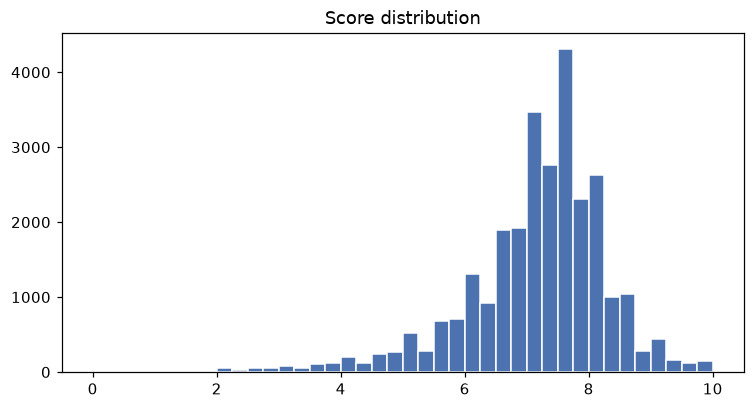

In [736]:
fig, ax = plt.subplots(figsize=(8, 4))
df["score"].dropna().plot(kind="hist", bins=40, ax=ax, color="#4C72B0", edgecolor="white")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Score distribution")
save_fig(fig, "01_score_distribution")
plt.show()

## Reviews per year

saved figures/02_reviews_per_year.png


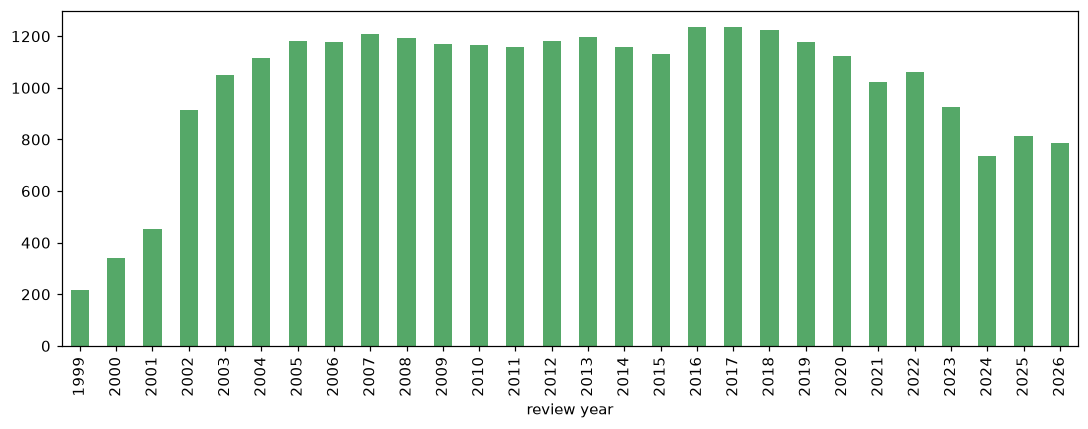

In [ ]:
by_year = df["review_year"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
by_year.plot(kind="bar", ax=ax, color="#55A868")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Reviews per year")
plt.xticks(rotation=90)
plt.tight_layout()
save_fig(fig, "02_reviews_per_year")
plt.show()

## Average score per year

In [ ]:
scores = df.groupby("review_year")["score"]
score_by_year = pd.DataFrame({
    "mean": scores.mean(),
    "median": scores.median(),
    "q1": scores.quantile(0.25),
    "q3": scores.quantile(0.75),
})

fig, ax = plt.subplots(figsize=(10, 4))
# the middle 50% of scores; min-max would be ~0 to 10 every year and flatten the lines
ax.fill_between(
    score_by_year.index, score_by_year["q1"], score_by_year["q3"],
    color="#C44E52", alpha=0.18, label="range (middle 50% of scores)",
)
ax.plot(score_by_year.index, score_by_year["mean"], marker="o", color="#C44E52", label="average")
ax.plot(score_by_year.index, score_by_year["median"], marker="s", linestyle="--", color="#4C72B0", label="median")
ax.set_xticks(score_by_year.index)                  # label every year, not every 5th
ax.tick_params(axis="x", rotation=90)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Score per year: average, median and range")
ax.legend(loc="lower right")
save_fig(fig, "03_score_per_year")
plt.show()

## Top genres

In [ ]:
genre_counts = genre_lists(df["genres"]).explode().value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 5))
genre_counts.sort_values().plot(kind="barh", ax=ax, color="#8172B2")
# plot out values of each row, with headroom on the right so the longest bar's label fits
top = genre_counts.max()
ax.set_xlim(0, top * 1.12)
for i, v in enumerate(genre_counts.sort_values()):
    ax.text(v + top * 0.01, i, str(v), color='black', va='center', fontweight='bold')
ax.set_xlabel("reviews")
ax.set_ylabel("")
ax.set_title("Pitchfork Genres")
plt.tight_layout()
save_fig(fig, "04_top_genres")
plt.show()

## Top countries

saved figures/05_top_countries.png


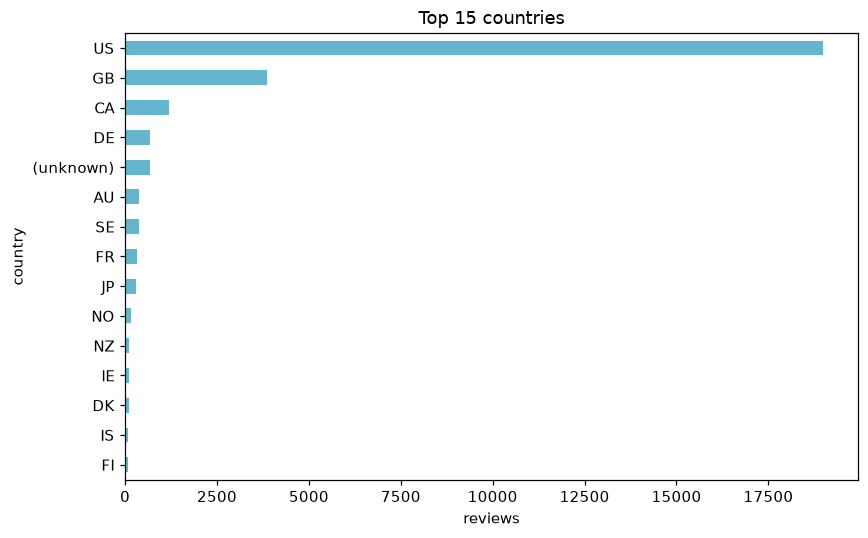

In [740]:
country_counts = df["country"].fillna("(unknown)").value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 5))
country_counts.sort_values().plot(kind="barh", ax=ax, color="#64B5CD")
ax.set_xlabel("reviews")
ax.set_title("Top 15 countries")
plt.tight_layout()
save_fig(fig, "05_top_countries")
plt.show()

## Score distribution by genre

Top 8 genres by review count.

saved figures/06_favourite_genres_boxplot.png


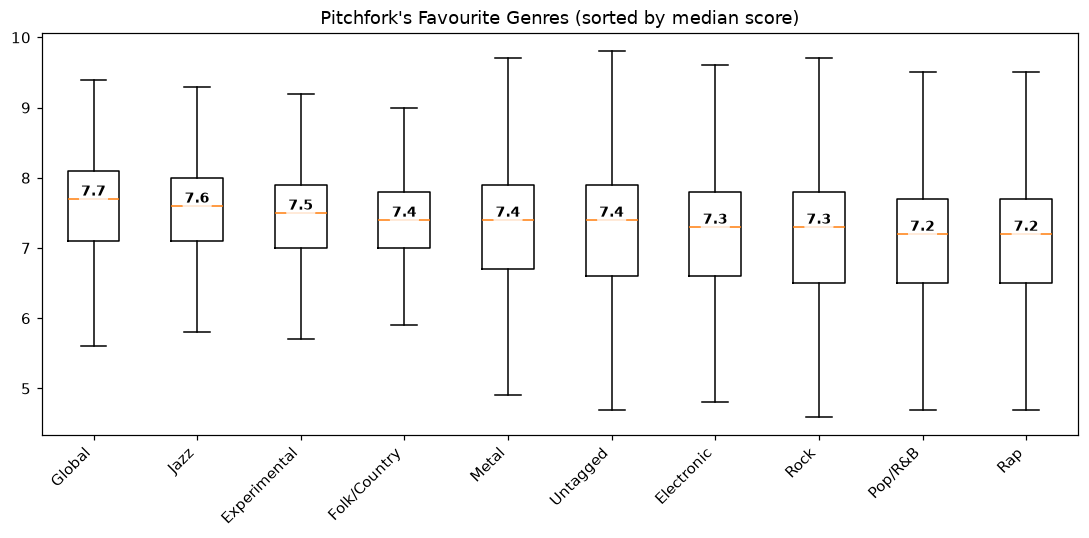

In [741]:
top_genres = genre_lists(df["genres"]).explode().value_counts().head(10).index
exploded = df.assign(genre_list=genre_lists(df["genres"])).explode("genre_list")
exploded = exploded[exploded["genre_list"].isin(top_genres)]

# order boxes by median score (highest first) so Pitchfork's favourite genre is
# immediately the leftmost box, and label each with its median for easy comparison
order = exploded.groupby("genre_list")["score"].median().sort_values(ascending=False).index
data = [exploded.loc[exploded["genre_list"] == g, "score"].dropna() for g in order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data, tick_labels=list(order), showfliers=False)
for i, scores in enumerate(data, start=1):
    med = scores.median()
    ax.text(
        i, med, f"{med:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8),
    )
ax.set_title("Pitchfork's Favourite Genres (sorted by median score)")
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig(fig, "06_favourite_genres_boxplot")
plt.show()

## Best New Music / Best New Reissue over time

saved figures/07_bnm_bnr_per_year.png


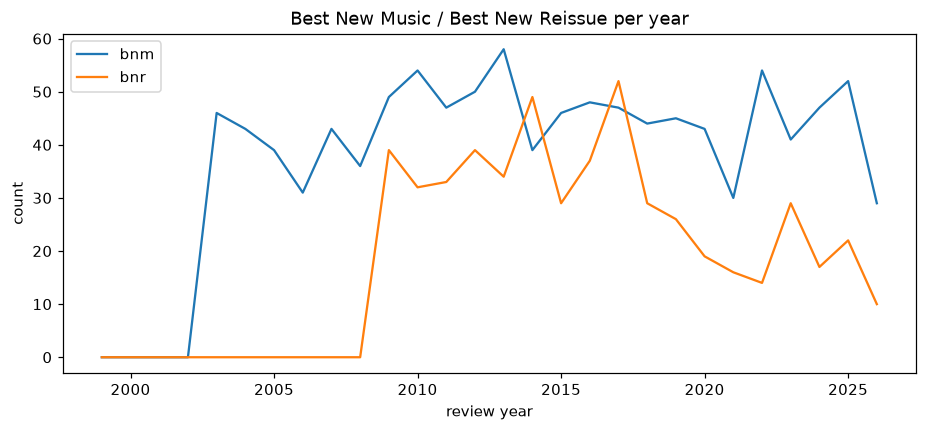

In [742]:
badges = df.groupby("review_year")[["bnm", "bnr"]].sum()
fig, ax = plt.subplots(figsize=(10, 4))
badges.plot(ax=ax)
ax.set_xlabel("review year")
ax.set_ylabel("count")
ax.set_title("Best New Music / Best New Reissue per year")
save_fig(fig, "07_bnm_bnr_per_year")
plt.show()

## Visualizing a saved selection

`fork.py` writes every filtered selection to `fork_selection_<filters>.tsv`. Load the most recent one here to chart just that subset — e.g. to sanity-check a playlist selection before exporting it.

loaded fork_selection_min9_max9.9_new.tsv: 296 rows


saved figures/fork_selection_min9_max9.9_new_score_distribution.png


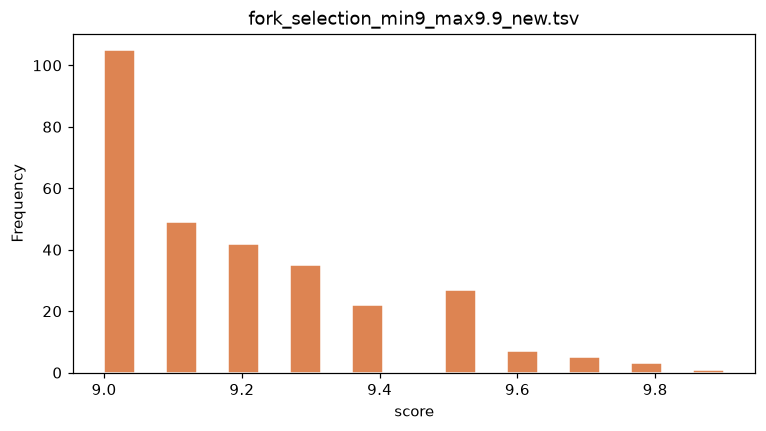

In [743]:
selection_files = sorted(project_dir.glob("filtered/fork_selection_*.tsv"))
if selection_files:
    sel = pd.read_csv(selection_files[-1], sep="\t")
    print(f"loaded {selection_files[-1].name}: {len(sel):,} rows")
    fig, ax = plt.subplots(figsize=(8, 4))
    sel["score"].plot(kind="hist", bins=20, ax=ax, color="#DD8452", edgecolor="white")
    ax.set_title(selection_files[-1].name)
    ax.set_xlabel("score")
    # named after the selection, so charts of different selections don't overwrite each other
    save_fig(fig, f"{selection_files[-1].stem}_score_distribution")
    plt.show()
else:
    print("no filtered/fork_selection_*.tsv found yet — run fork.py with some filters first")